In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df = pd.read_csv('AIML Dataset.csv')
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [ ]:
df.shape

(6362620, 9)

In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [ ]:
df["isFraud"].value_counts()


,count
isFraud,
0,6354407
1,8213


In [ ]:
df["isFraud"].unique()

array([0, 1])

In [ ]:
df["isFlaggedFraud"].value_counts()

,count
isFlaggedFraud,
0,6362604
1,16


In [ ]:
percantageFraud = df["isFraud"].value_counts()[1.0] / df.shape[0]
percantageFraud*100

np.float64(0.12908204481801522)

In [ ]:
percantageNotFraud = df["isFraud"].value_counts()[0.0] / df.shape[0]
percantageNotFraud * 100

np.float64(99.87091795518198)

In [ ]:
print((percantageFraud*100) + (percantageNotFraud * 100))

100.0


In [ ]:
df["type"].values

array(['PAYMENT', 'PAYMENT', 'TRANSFER', ..., 'CASH_OUT', 'TRANSFER',
       'CASH_OUT'], dtype=object)

In [ ]:
FraudbyType = df.groupby('type')["isFraud"].mean().sort_values()


In [ ]:
FraudbyType*100

,isFraud
type,
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000
CASH_OUT,0.183955
TRANSFER,0.768799


In [ ]:
df["amount"].describe().astype(int)

,amount
count,6362620
mean,179861
std,603858
min,0
25%,13389
50%,74871
75%,208721
max,92445516


<Axes: xlabel='isFraud', ylabel='amount'>

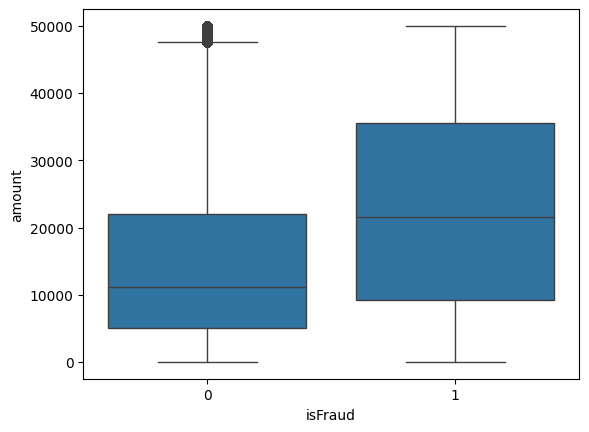

In [ ]:
sns.boxplot (data = df[df["amount"] < 50000], x= "isFraud" , y="amount" )

<Axes: xlabel='isFraud', ylabel='amount'>

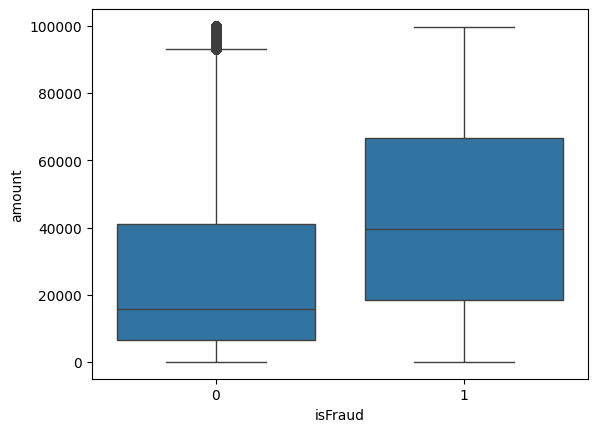

In [ ]:
sns.boxplot (data = df[df["amount"] < 100000], x= "isFraud" , y="amount" )

<Axes: xlabel='isFraud', ylabel='amount'>

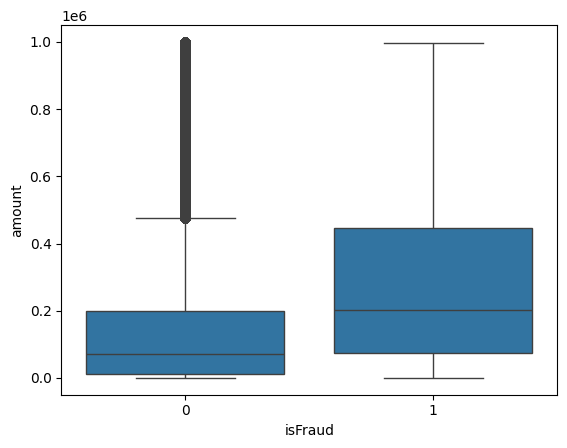

In [ ]:
sns.boxplot (data = df[df["amount"] < 1000000], x= "isFraud" , y="amount" )

In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df ["balancediffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balancediffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]


In [ ]:
#Accounts whose balance become 0 after transactions
(df["balancediffOrig"] < 0).sum()
#Accounts whose balance become 0 after transactions percantage out of total accounts
origZeroPerc = (df["balancediffOrig"] < 0).sum() / df.shape[0] * 100
origZeroPerc

np.float64(21.99177382902012)

In [ ]:
#Accounts whose balance become 0 after transactions
(df["balancediffDest"] < 0).sum()
#Accounts whose balance become 0 after transactions percantage out of total accounts
destZeroPerc = (df["balancediffDest"] < 0).sum() / df.shape[0] * 100
destZeroPerc

np.float64(19.470972649631754)

In [ ]:
top_senders = df["nameOrig"].value_counts().head(5)
top_senders

,count
nameOrig,
C1530544995,3
C545315117,3
C724452879,3
C1784010646,3
C1677795071,3


In [ ]:
least_senders = df["nameOrig"].value_counts().tail(5)
least_senders

,count
nameOrig,
C1567523029,1
C644777639,1
C1256645416,1
C1231536757,1
C1971151096,1


In [ ]:
top_reciever = df["nameDest"].value_counts().head(5)
top_reciever

,count
nameDest,
C1286084959,113
C985934102,109
C665576141,105
C2083562754,102
C248609774,101


In [ ]:
least_reciever = df["nameDest"].value_counts().tail(5)
least_reciever

,count
nameDest,
M367627425,1
M1902904124,1
M242332837,1
M281573812,1
M1010678443,1


In [ ]:
fraud_users = df[df["isFraud"] ==1] ["nameOrig"].value_counts().head(10)

In [ ]:
fraud_users

,count
nameOrig,
C1280323807,1
C1305486145,1
C840083671,1
C1420196421,1
C2101527076,1
C1039979813,1
C2089752665,1
C1614818636,1
C40604503,1


In [ ]:
fraud_ratio_by_type = df.groupby('type')['isFraud'].mean()
fraud_ratio_by_type = fraud_ratio_by_type.sort_values(ascending=False)


In [ ]:
fraud_ratio_by_type*100

,isFraud
type,
TRANSFER,0.768799
CASH_OUT,0.183955
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000


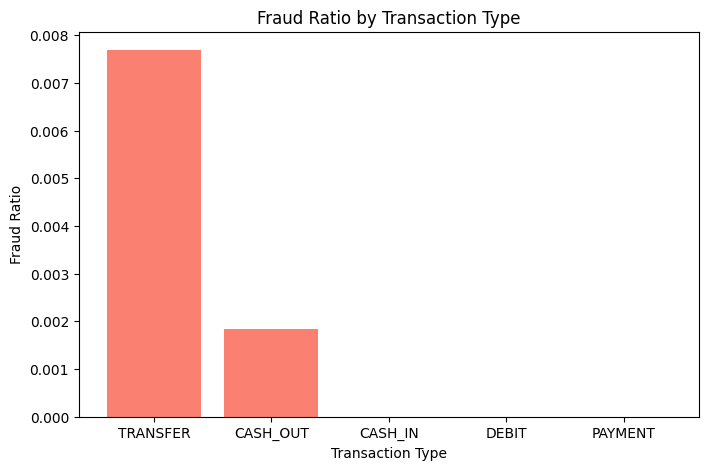

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(fraud_ratio_by_type.index, fraud_ratio_by_type.values, color='salmon')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Ratio')
plt.title('Fraud Ratio by Transaction Type')
plt.show()

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 13 columns):
 #   Column           Dtype  
---  ------           -----  
 0   step             int64  
 1   type             object 
 2   amount           float64
 3   nameOrig         object 
 4   oldbalanceOrg    float64
 5   newbalanceOrig   float64
 6   nameDest         object 
 7   oldbalanceDest   float64
 8   newbalanceDest   float64
 9   isFraud          int64  
 10  isFlaggedFraud   int64  
 11  balancediffOrig  float64
 12  balancediffDest  float64
dtypes: float64(7), int64(3), object(3)
memory usage: 631.1+ MB


In [ ]:
df.drop(["nameOrig", "nameDest", "step", "isFlaggedFraud"], axis=1, inplace=True)


In [ ]:
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balancediffOrig,balancediffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 9 columns):
 #   Column           Dtype  
---  ------           -----  
 0   type             object 
 1   amount           float64
 2   oldbalanceOrg    float64
 3   newbalanceOrig   float64
 4   oldbalanceDest   float64
 5   newbalanceDest   float64
 6   isFraud          int64  
 7   balancediffOrig  float64
 8   balancediffDest  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 436.9+ MB


In [ ]:
df['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [ ]:

X = df.drop("isFraud", axis=1)
y = df["isFraud"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
numeric = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
           'oldbalanceDest', 'newbalanceDest',
           'balancediffOrig', 'balancediffDest']

categorical = ['type']

In [ ]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical)
    ]
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

Train shape: (5090096, 11)
Test shape: (1272524, 11)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, f1_score



In [ ]:
# Logistic Regression
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_processed, y_train)
y_pred_logreg = logreg.predict(X_test_processed)
f1_logreg = f1_score(y_test, y_pred_logreg)
print("Logistic Regression F1 Score:", f1_logreg)
print(classification_report(y_test, y_pred_logreg))



Logistic Regression F1 Score: 0.04370074855153164
              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1270881
           1       0.02      0.94      0.04      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.95      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



In [ ]:
# SGDClassifier
sgd = SGDClassifier(
    loss='log_loss',
    class_weight='balanced',
    max_iter=1000,
    tol=1e-3,
    random_state=42
)
sgd.fit(X_train_processed, y_train)
y_pred_sgd = sgd.predict(X_test_processed)
f1_sgd = f1_score(y_test, y_pred_sgd)
print("SGDClassifier F1 Score:", f1_sgd)
print(classification_report(y_test, y_pred_sgd))



SGDClassifier F1 Score: 0.04370183570251194
              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1270881
           1       0.02      0.94      0.04      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.95      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



In [ ]:
# Compare and select best model
if f1_logreg > f1_sgd:
    best_model_name = "Logistic Regression"
    best_f1 = f1_logreg
    best_model = logreg
elif f1_sgd > f1_logreg :
    best_model_name = "SGD Classifier"
    best_f1 = f1_sgd
    best_model = sgd
else:
    print("Both models have the same F1 score. so we select ")
    best_model_name = "Logistic Regression"
    best_f1 = f1_logreg
    best_model = logreg


print(f"\n✅ Best Model: {best_model_name} with F1 Score: {best_f1:.4f}")



✅ Best Model: SGD Classifier with F1 Score: 0.0437


In [ ]:
fraud_rows = df[df['isFraud'] == 1]
print(fraud_rows.head(2))

df.head(2)

       type  amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
2  TRANSFER   181.0          181.0             0.0             0.0   
3  CASH_OUT   181.0          181.0             0.0         21182.0   

   newbalanceDest  isFraud  balancediffOrig  balancediffDest  
2             0.0        1            181.0              0.0  
3             0.0        1            181.0         -21182.0  


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balancediffOrig,balancediffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0


In [ ]:

amount = float(input("Enter transaction amount: "))
oldbalanceOrg = float(input("Enter old balance of sender: "))
newbalanceOrig = float(input("Enter new balance of sender: "))
oldbalanceDest = float(input("Enter old balance of receiver: "))
newbalanceDest = float(input("Enter new balance of receiver: "))
balancediffOrig = oldbalanceOrg - newbalanceOrig
balancediffDest = newbalanceDest - oldbalanceDest
tx_type = input("Enter transaction type (PAYMENT, TRANSFER, CASH_OUT, DEBIT, CASH_IN): ")


input_dict = {
    'amount': [amount],
    'oldbalanceOrg': [oldbalanceOrg],
    'newbalanceOrig': [newbalanceOrig],
    'oldbalanceDest': [oldbalanceDest],
    'newbalanceDest': [newbalanceDest],
    'balancediffOrig': [balancediffOrig],
    'balancediffDest': [balancediffDest],
    'type': [tx_type]
}

input_df = pd.DataFrame(input_dict)


input_processed = preprocessor.transform(input_df)


prediction = best_model.predict(input_processed)[0]  # 0 or 1


if prediction == 1:
    print("\n⚠️ This transaction is predicted as FRAUD.")
else:
    print("\n✅ This transaction is predicted as NOT FRAUD.")


Enter transaction amount: 191.0
Enter old balance of sender: 200
Enter new balance of sender: 8.9
Enter old balance of receiver: 70
Enter new balance of receiver: 261
Enter transaction type (PAYMENT, TRANSFER, CASH_OUT, DEBIT, CASH_IN): PAYMENT

✅ This transaction is predicted as NOT FRAUD.
